<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/Copia_de_prediccion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este cuaderno constituye el núcleo tecnológico del TFM. Se presenta un flujo de trabajo completo de **Data Science** aplicado a la monitorización ambiental, diseñado para ser replicable en el aula de Tecnología.

### 🎯 Objetivos
*   **Analizar** grandes volúmenes de datos procedentes del servicio CAMS (Copernicus Atmospheric Monitoring Service).
*   **Correlacionar** variables meteorológicas (Temperatura, Humedad, Viento) con contaminantes atmosféricos.
*   **Implementar** un modelo de Inteligencia Artificial basado en redes **LSTM** para la predicción de partículas $PM_{10}$.

### 🛠️ Especificaciones del Laboratorio de Datos
*   **Fuentes:** Reanálisis ERA5-Land y CAMS Global Atmospheric Composition.
*   **Volumen de Datos:** ~30 GB (Procesados mediante acceso directo en Google Drive).
*   **Infraestructura:** Google Colab con soporte de GPU/TPU para el entrenamiento del modelo.

### 📚 Alineación Curricular (LOMLOE)
Este ejercicio práctico desarrolla las siguientes competencias en el alumnado de Bachillerato:
1.  **Pensamiento Computacional:** Programación en Python y gestión de estructuras de datos masivas.
2.  **Competencia STEM:** Aplicación de modelos matemáticos a problemas ambientales reales.
3.  **Alfabetización Algorítmica:** Comprensión del funcionamiento y ética de los sistemas de IA.

---

In [1]:
#@title Conexión a Drive y Carga de Ficheros { display-mode: "form" }
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import os
from google.colab import drive

# 1. Montar el Google Drive del usuario actual
drive.mount('/content/drive')

# 2. Definir la ruta donde debería estar el acceso directo
# Nota: "Datos_Publicos_TFM" es el nombre de la carpeta donde está el código
PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"

# 3. Verificar si los archivos están presentes
archivodatos = os.path.join(PATH_BASE, "Murcia_Dataset_Completo_Global_3H.parquet")


Mounted at /content/drive


Analizamos la correlación entre variables para validar la influencia de la meteorología en los contaminantes.
*   **Hipótesis:** La radiación y la temperatura tienen una correlación directa con los niveles de Ozono ($O_3$).
*   **Método:** Matriz de correlación de Pearson y remuestreo mensual.

Dataset cargado: 438360 registros, 18 variables.


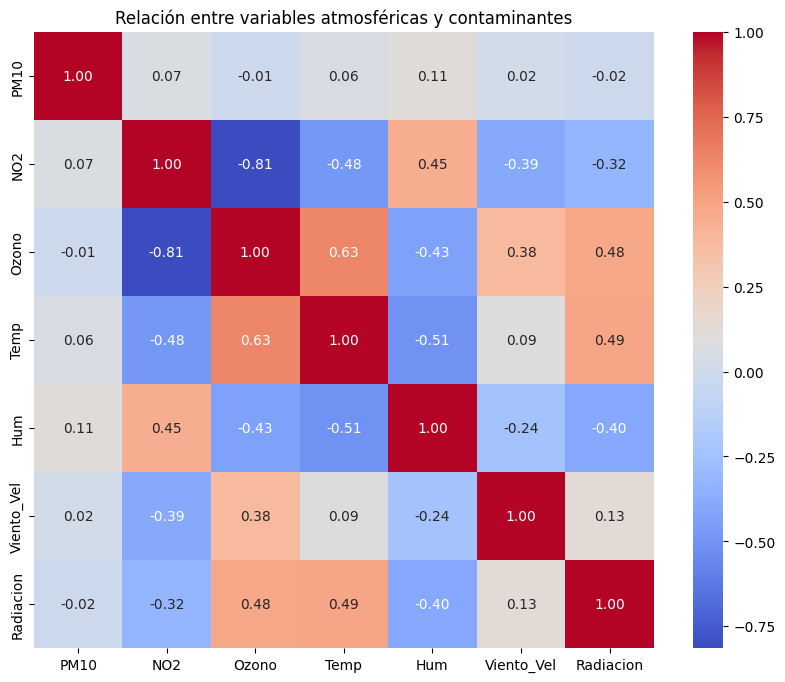

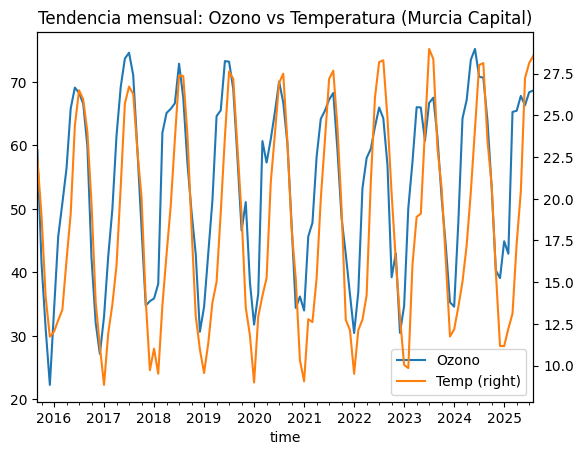

In [2]:
#@title 📈 Generación de Visualizaciones { display-mode: "form" }
# --- FASE 1: CARGA Y EDA ---
df = pd.read_parquet(archivodatos)
print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} variables.")

# 1. Correlación Multivariante
plt.figure(figsize=(10,8))
corr = df[['PM10', 'NO2', 'Ozono', 'Temp', 'Hum', 'Viento_Vel', 'Radiacion']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Relación entre variables atmosféricas y contaminantes")
plt.savefig("correlacion_variables.png") # Guardamos para el TFM
plt.show()

# 2. Perfil estacional
df['time'] = pd.to_datetime(df['time']) # Asegurar formato fecha
estacion_ejemplo = df[df['Estacion'] == 'Murcia Capital']
estacion_ejemplo.set_index('time')[['Ozono', 'Temp']].resample('ME').mean().plot(secondary_y='Temp')
plt.title("Tendencia mensual: Ozono vs Temperatura (Murcia Capital)")
plt.savefig("tendencia_estacional.png") # Guardamos para el TFM
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 140s 11ms/step - loss: 3.0277e-04 - val_loss: 2.1894e-04
Epoch 2/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 130s 11ms/step - loss: 2.6013e-04 - val_loss: 2.0379e-04
Epoch 3/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 133s 11ms/step - loss: 2.4931e-04 - val_loss: 1.9804e-04
Epoch 4/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 132s 11ms/step - loss: 2.4390e-04 - val_loss: 2.0891e-04
Epoch 5/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 132s 11ms/step - loss: 2.3861e-04 - val_loss: 1.9753e-04
Epoch 6/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 142s 11ms/step - loss: 2.3584e-04 - val_loss: 2.0323e-04
Epoch 7/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 133s 11ms/step - loss: 2.3146e-04 - val_loss: 2.2570e-04
Epoch 8/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 140s 11ms/step - loss: 2.2743e-04 - val_loss: 1.9691e-04
Epoch 9/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - loss: 2.2424e-04 - val_loss: 1.9251e-04
Epoch 10/20
12329/12329 ━━━━━━━━━━━━━━━━━━━━ 142s 11ms/step - loss: 2.2119e-04 - val_loss: 

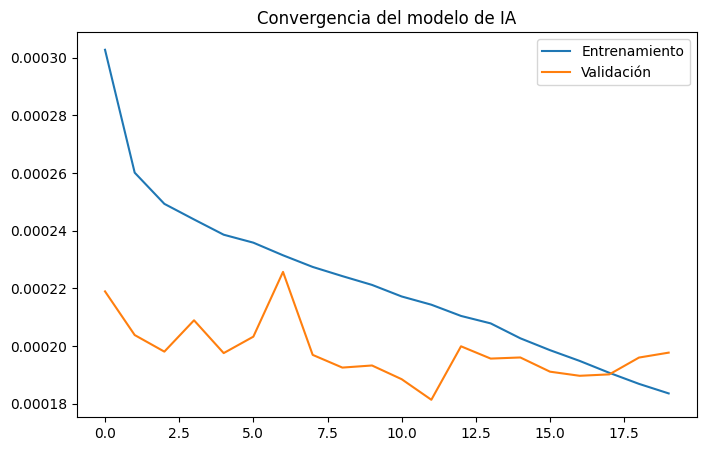

In [3]:
#@title 🚀 Configuración y Entrenamiento del Modelo { display-mode: "form" }
# --- FASE 2: ENTRENAMIENTO LSTM ---
features = ['PM10', 'Temp', 'Hum', 'Viento_Vel', 'Radiacion']
data = df[features].values
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

def create_sequences(data, seq_length=8):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

X, y = create_sequences(data_scaled)

# Definir modelo
model = tf.keras.Sequential([
    # Añadimos esta capa explícita para definir la entrada
    tf.keras.layers.Input(shape=(8, 5)),

    tf.keras.layers.LSTM(50, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(50),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Entrenamiento
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Visualización del progreso
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.legend()
plt.title("Convergencia del modelo de IA")
plt.savefig("convergencia_modelo.png") # Guardamos para el TFM
plt.show()

# --- FASE 3: EXPORTACIÓN DE RESULTADOS ---
# Guardar el modelo
model.save("modelo_calidad_aire_murcia.keras")

In [4]:
#@title 💾 Guardar Resultados { display-mode: "form" }
print("\n--- 🚀 PROCESO COMPLETADO ---")
print("✅ Archivo del modelo: 'modelo_calidad_aire_murcia.keras'")
print("✅ Gráficos exportados: 'correlacion_variables.png', 'tendencia_estacional.png', 'convergencia_modelo.png'")
print("Descárgalos desde la pestaña de Archivos (icono de carpeta a la izquierda) en Colab.")


--- 🚀 PROCESO COMPLETADO ---
✅ Archivo del modelo: 'modelo_calidad_aire_murcia.keras'
✅ Gráficos exportados: 'correlacion_variables.png', 'tendencia_estacional.png', 'convergencia_modelo.png'
Descárgalos desde la pestaña de Archivos (icono de carpeta a la izquierda) en Colab.
